The Nobel Prize has been among the most prestigious international awards since 1901. Each year, awards are bestowed in chemistry, literature, physics, physiology or medicine, economics, and peace. In addition to the honor, prestige, and substantial prize money, the recipient also gets a gold medal with an image of Alfred Nobel (1833 - 1896), who established the prize.

![](Nobel_Prize.png)

The Nobel Foundation has made a dataset available of all prize winners from the outset of the awards from 1901 to 2023. The dataset used in this project is from the Nobel Prize API and is available in the `nobel.csv` file in the `data` folder.

In this project, you'll get a chance to explore and answer several questions related to this prizewinning data. And we encourage you then to explore further questions that you're interested in!

In [158]:
# Loading in required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("data/nobel.csv")
df.head()

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France


In [159]:
# What is the most commonly awarded gender and birth country?
gender_counts = df["sex"].value_counts()
print(gender_counts)
top_gender = "Male"

Male      905
Female     65
Name: sex, dtype: int64


In [160]:
# What is the most commonly awarded gender and birth country?
country_counts = df["birth_country"].value_counts()
print(country_counts.head())
top_country = "United States of America"

United States of America    291
United Kingdom               91
Germany                      67
France                       58
Sweden                       30
Name: birth_country, dtype: int64


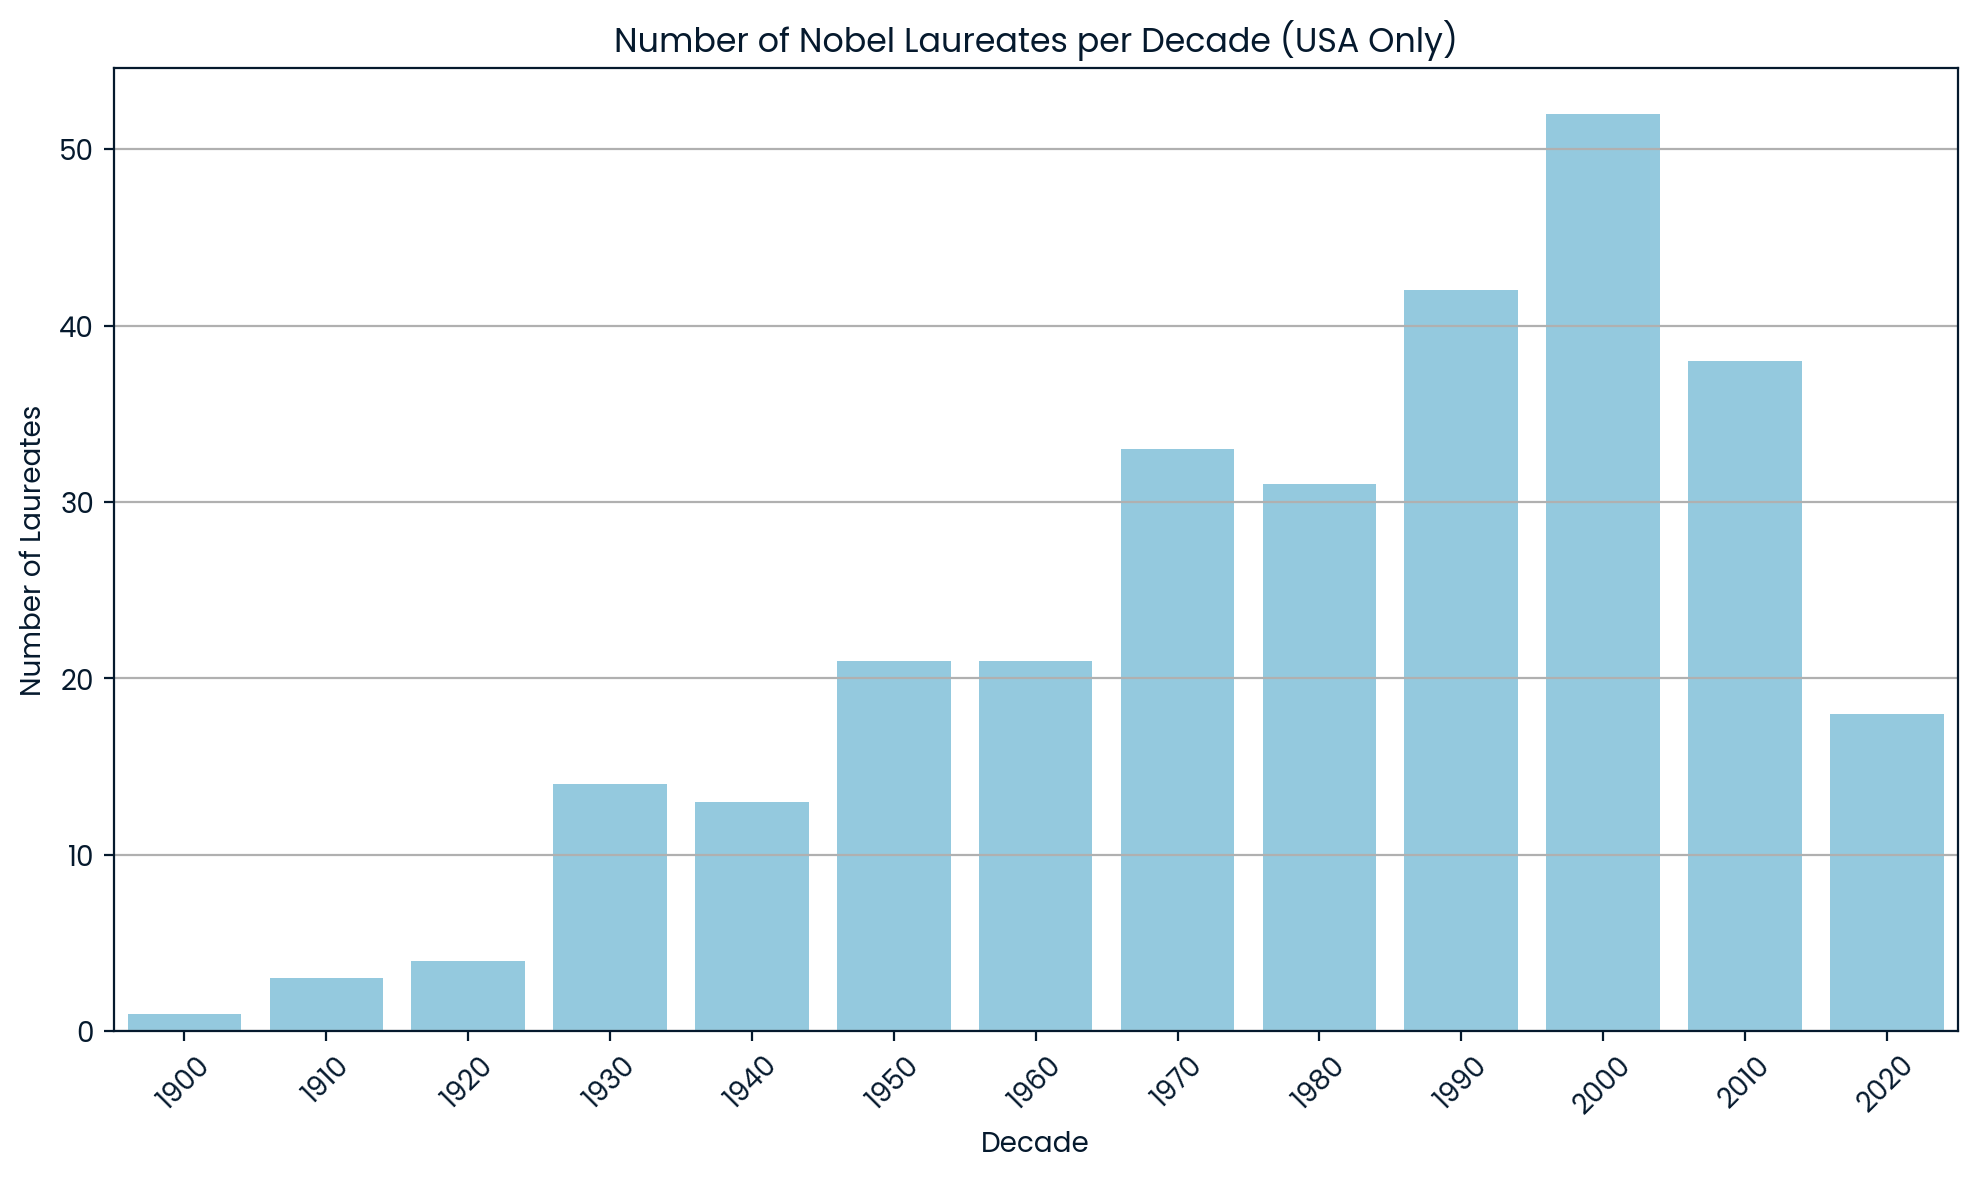

In [161]:
# Which decade had the highest ratio of US-born Nobel Prize winners to total winners in all categories?

df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna(subset=['year'])
df['year'] = df['year'].astype(int)

df['decade'] = (df['year'] // 10) * 10

usa_df = df[df['birth_country'] == 'United States of America']
usa_decade_counts['decade'] = usa_decade_counts['decade'].astype(str)

plt.figure(figsize=(10,6))
sns.barplot(data=usa_decade_counts, x='decade', y='laureate_count', color='skyblue')
plt.title('Number of Nobel Laureates per Decade (USA Only)')
plt.xlabel('Decade')
plt.ylabel('Number of Laureates')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

max_decade_usa = 2000

In [162]:
# Which decade and Nobel Prize category combination had the highest proportion of female laureates?
women_df = df[df["sex"] == "Female"]
female_count = women_df.groupby(["decade", "category"]).size()
total_count = df.groupby(["decade", "category"]).size()
proportion_percent = ((female_count / total_count) * 100).sort_values(ascending=False)
print(proportion)

max_female_dict = {2020 : "Literature"}


decade  category  
2020    Literature    50.000000
2010    Peace         35.714286
2000    Literature    30.000000
1990    Literature    30.000000
2010    Literature    30.000000
                        ...    
1980    Physics             NaN
1990    Chemistry           NaN
        Economics           NaN
        Physics             NaN
2000    Physics             NaN
Length: 72, dtype: float64


In [163]:
# Who was the first woman to receive a Nobel Prize, and in what category?

women_df = women_df.sort_values("year", ascending=True)
women_df.head()
first_woman_name = women_df.iloc[0].full_name
first_woman_category = women_df.iloc[0].category

In [164]:
# Which individuals or organizations have won more than one Nobel Prize throughout the years?
winners = df.groupby("full_name").size().reset_index(name="prize_count")
repeat_winners = winners[winners["prize_count"] > 1].sort_values("prize_count", ascending=False)

# If name is attached, it means the org did not win
# Need to filter for rows where org is present but not full_name
org_only = df[df["full_name"].isna() & df["organization_name"].notna()]
org_winners = org_only.groupby("organization_name").size().reset_index(name="prize_count")
repeat_orgs = org_winners[org_winners['prize_count'] > 1]

repeat_list = repeat_winners['full_name'].unique().tolist()
repeat_list.extend(repeat_orgs['organization_name'].unique().tolist())

print(repeat_list)

['Comité international de la Croix Rouge (International Committee of the Red Cross)', 'Frederick Sanger', 'John Bardeen', 'Linus Carl Pauling', 'Marie Curie, née Sklodowska', 'Office of the United Nations High Commissioner for Refugees (UNHCR)']
